# Fine Tuning BERT for Sentiment Analysis with PyTorch

References:
- [Fine Tuning BERT for Sentiment Analysis with PyTorch](https://wellsr.com/python/fine-tuning-bert-for-sentiment-analysis-with-pytorch/)
- [Twitter US Airline Sentiment](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?select=Tweets.csv)

- [RuntimeError: CUDA out of memory during loss.backward()](https://discuss.pytorch.org/t/runtimeerror-cuda-out-of-memory-during-loss-backward/53450/6)
- [Forms - Colaboratory](https://colab.research.google.com/notebooks/forms.ipynb)
- [Plotting loss curve](https://discuss.pytorch.org/t/plotting-loss-curve/42632/5)
- [Estratégias eficazes para lidar com conjuntos de dados desbalanceados](https://medium.com/@daniele.santiago/estrat%C3%A9gias-eficazes-para-lidar-com-conjuntos-de-dados-desbalanceados-5b873894483b)
- [Aprenda a balancear seus dados com Undersampling e Oversampling em Python](https://medium.com/@daniele.santiago/aprenda-a-balancear-seus-dados-com-undersampling-e-oversampling-em-python-6fd87095d717#:~:text=J%C3%A1%20o%20over%2Dsampling%2C%20por,t%C3%A9cnicas%20foi%20explicitada%20neste%20artigo.)
- [RandomOverSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html#imblearn.over_sampling.RandomOverSampler.fit_resample)
- [REPRODUCIBILITY](https://pytorch.org/docs/stable/notes/randomness.html)

In [43]:
# @title Environment running
running_local = False
if running_local:
    running_colab = running_kaggle = False
else:
    running_colab = True  # @param {type:"boolean"}
    running_kaggle = not running_colab  # @param {type:"boolean"}

In [44]:
if running_colab:
    from google.colab import drive

    drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Installing and Importing Required Libraries

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
import seaborn as sns
import time
import torch
import torch.nn as nn

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel

## Config

In [46]:
RANDOM_SEED = 103
TEST_SIZE = 0.2
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 5

TOKEN_MAX_LENGTH = 512
PRETRAINED_MODEL_PATH = "neuralmind/bert-base-portuguese-cased"
BERTIMBAU_HIDDEN_SIZE = 768

SAMPLE_REVIEWS = [
    "Empresa boa para trabalhar", # positive
    "Empresa ruim para trabalhar", # negative
    "Não tenho o que declarar", # neutral
]


if running_colab:
    GLASSDOOR_MODEL_PATH = "/content/drive/MyDrive/UFMT/Gestão e Ciência de Dados/Disciplinas/14 - Seminário e Metodologia da Pesquisa/Projetos/glassdoor-reviews-analysis-nlp/train_model/bertimbau-glassdoor-reviews-no-layer.bin"
    GLASSDOOR_FREEZING_MODEL_PATH = "/content/drive/MyDrive/UFMT/Gestão e Ciência de Dados/Disciplinas/14 - Seminário e Metodologia da Pesquisa/Projetos/glassdoor-reviews-analysis-nlp/train_model/bertimbau-glassdoor-reviews-freezing-no-layer.bin"
    PATH_TO_SAVE_MODEL = "/content/drive/MyDrive/UFMT/Gestão e Ciência de Dados/Disciplinas/14 - Seminário e Metodologia da Pesquisa/Projetos/glassdoor-reviews-analysis-nlp/train_model/"
if running_kaggle:
    GLASSDOOR_MODEL_PATH = "/kaggle/working/bertimbau-glassdoor-reviews-no-layer.bin"
    GLASSDOOR_FREEZING_MODEL_PATH = (
        "/kaggle/working/bertimbau-glassdoor-reviews-freezing-no-layer.bin"
    )
    PATH_TO_SAVE_MODEL = "/kaggle/working/"
if running_local:
    GLASSDOOR_MODEL_PATH = "./bertimbau-glassdoor-reviews-no-layer.bin"
    GLASSDOOR_FREEZING_MODEL_PATH = "./bertimbau-glassdoor-reviews-freezing-no-layer.bin"
    PATH_TO_SAVE_MODEL = "./train_model/"

In [47]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"There are {torch.cuda.device_count()} GPU(s) available.")
    print("Device name:", torch.cuda.get_device_name(0))
else:
    print("No GPU available, using the CPU instead.")
    device = torch.device("cpu")

There are 1 GPU(s) available.
Device name: Tesla T4


In [48]:
torch.manual_seed(RANDOM_SEED)

In [49]:
random.seed(RANDOM_SEED)

In [50]:
np.random.seed(RANDOM_SEED)

## Importing and Preprocessing the Dataset

In [51]:
if running_colab:
    dataset = pd.read_csv(
        "/content/drive/MyDrive/UFMT/Gestão e Ciência de Dados/Disciplinas/14 - Seminário e Metodologia da Pesquisa/Projetos/glassdoor-reviews-analysis-nlp/data_preparation/glassdoor_reviews_annotated.csv"
    )
else:
    if running_kaggle:
        dataset = pd.read_csv(
            "/kaggle/input/glassdoor-reviews-annotated/glassdoor_reviews_annotated.csv"
        )
    else:
        dataset = pd.read_csv("../data_preparation/glassdoor_reviews_annotated.csv")

In [52]:
dataset.head(2)

,review_id,company,employee_role,employee_detail,review_text,review_date,star_rating,sentiment,annotated
0,82630669,Tecnomapas,Recepcionista,"Ex-funcionário(a), mais de um ano","Companheirismo entre os colegas, oportunidade ...",2023-12-15,5.0,1,0
1,82630669,Tecnomapas,Recepcionista,"Ex-funcionário(a), mais de um ano",Não tive nenhum ponto negativo,2023-12-15,5.0,0,1


In [53]:
filtered_dataset = dataset.filter(["review_text", "sentiment"])

In [54]:
filtered_dataset.shape

(2532, 2)

In [55]:
filtered_dataset["sentiment"].value_counts()

,count
sentiment,
1,1269
-1,1021
0,242


In [56]:
num_labels = len(filtered_dataset["sentiment"].value_counts())

In [57]:
num_labels

3

In [58]:
filtered_dataset.head()

,review_text,sentiment
0,"Companheirismo entre os colegas, oportunidade ...",1
1,Não tive nenhum ponto negativo,0
2,Equipe bem prestativa e ótima de se trabalhar.,1
3,Modo home office ainda tem que ser melhorado.,-1
4,Única vantagem era o trabalho ser home office,0


Replace negative sentiment (-1) to 2, to avoid PyTorch errors.

In [59]:
filtered_dataset["sentiment"] = filtered_dataset["sentiment"].apply(
    lambda x: 2 if x == -1 else x
)

In [60]:
filtered_dataset.head()

,review_text,sentiment
0,"Companheirismo entre os colegas, oportunidade ...",1
1,Não tive nenhum ponto negativo,0
2,Equipe bem prestativa e ótima de se trabalhar.,1
3,Modo home office ainda tem que ser melhorado.,2
4,Única vantagem era o trabalho ser home office,0


Shuffle the data before splitting it into training and testing sets to remove any inherent ordering in the data that could bias the model's learning process.

In [61]:
filtered_dataset = filtered_dataset.sample(frac=1, random_state=RANDOM_SEED)

In [62]:
train_data, test_data = train_test_split(
    filtered_dataset, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

In [63]:
train_data.shape

(2025, 2)

In [64]:
test_data.shape

(507, 2)

## Loading Bertimbau model

In [65]:
bertimbau = BertModel.from_pretrained(PRETRAINED_MODEL_PATH)

In [66]:
tokenizer = BertTokenizer.from_pretrained(PRETRAINED_MODEL_PATH)

## Create a PyTorch Dataset

In [67]:
class GlassdoorReviewsDataset(Dataset):
    def __init__(self, data, tokenizer, token_max_length):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = token_max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        text = self.data.iloc[index]["review_text"]
        labels = self.data.iloc[index][["sentiment"]].values.astype(int)

        encoding = self.tokenizer(
            text,
            return_tensors="pt",
            padding=True,
            truncation=False,
            # max_length=self.max_length,
        )
        input_ids = encoding["input_ids"][0]
        attention_mask = encoding["attention_mask"][0]

        # resize the tensors to the same size
        input_ids = nn.functional.pad(
            input_ids, (0, self.max_length - input_ids.shape[0]), value=0
        )
        attention_mask = nn.functional.pad(
            attention_mask, (0, self.max_length - attention_mask.shape[0]), value=0
        )

        return input_ids, attention_mask, torch.tensor(labels)

In [68]:
train_dataset = GlassdoorReviewsDataset(train_data, tokenizer, TOKEN_MAX_LENGTH)
test_dataset = GlassdoorReviewsDataset(test_data, tokenizer, TOKEN_MAX_LENGTH)

In [69]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Creating a PyTorch Model

In [70]:
classifier = nn.Sequential(
    nn.Linear(BERTIMBAU_HIDDEN_SIZE, num_labels)
)

In [71]:
class GlassdoorReviewsClassifier(nn.Module):
    def __init__(self, num_labels):
        super(GlassdoorReviewsClassifier, self).__init__()

        self.bert = BertModel.from_pretrained(PRETRAINED_MODEL_PATH)
        self.classifier = classifier


    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = outputs["last_hidden_state"][:, 0, :]
        x = self.classifier(x)
        return x

In [72]:
class GlassdoorReviewsClassifierFreezing(nn.Module):
    def __init__(self, num_labels):
        super(GlassdoorReviewsClassifierFreezing, self).__init__()

        for param in bertimbau.parameters():
            param.requires_grad = False

        self.bert = BertModel.from_pretrained(PRETRAINED_MODEL_PATH)
        self.classifier = classifier

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = outputs["last_hidden_state"][:, 0, :]
        x = self.classifier(x)
        return x

## Model training functions

In [73]:
def train(model, data_loader, loss_fun, optimizer, n_total_steps):
    model.train()

    running_loss = 0.0
    for i, batch in enumerate(data_loader):
        input_ids, attention_mask, labels = batch

        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        labels = labels.view(-1)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)

        loss = loss_fun(logits, labels)

        loss.backward()
        optimizer.step()

        loss_value = loss.item()
        running_loss += loss_value

        if (i + 1) % BATCH_SIZE == 0:
            print(
                f"Training Batch {i + 1}/{n_total_steps}, \t\t loss = {loss_value:.4f}"
            )

    return running_loss / len(data_loader)

In [74]:
def test(model, data_loader, loss_fun, n_total_steps):
    model.eval()

    running_loss = 0.0
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            input_ids, attention_mask, labels = batch

            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            labels = labels.view(-1)
            labels = labels.to(device)

            logits = model(input_ids, attention_mask)
            loss = loss_fun(logits, labels)

            loss_value = loss.item()
            running_loss += loss_value

            if (i + 1) % BATCH_SIZE == 0:
                print(
                    f"Evaluating Batch {i + 1}/{n_total_steps}, \t\t loss = {loss_value:.4f}"
                )

    return running_loss / len(data_loader)

In [75]:
def show_loss(train_loss_per_epoch, test_loss_per_epoch, title):
    epochs = range(1, len(train_loss_per_epoch) + 1)

    train_data = {"epoch": epochs, "loss": train_loss_per_epoch, "type": "Train"}
    test_data = {"epoch": epochs, "loss": test_loss_per_epoch, "type": "Test"}
    df_loss = pd.concat([pd.DataFrame(train_data), pd.DataFrame(test_data)])

    plt.figure(figsize=(8, 6))
    sns.lineplot(data=df_loss, x="epoch", y="loss", hue="type", marker="o")

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    # plt.grid(True)
    plt.legend(title="Loss Type")
    plt.show()

In [77]:
def start_training(model, train_loader, loss_fun, optimizer, epochs, n_total_steps):
    train_losses = []
    test_losses = []
    start_time = time.time()

    for t in range(epochs):
        print(f"{'-'*20} Epoch: {t + 1}/{epochs} {'-'*20}")

        train_loss = train(model, train_loader, loss_fun, optimizer, n_total_steps)
        train_losses.append(train_loss)

        print("")

        test_loss = test(model, test_loader, loss_fun, n_total_steps)
        test_losses.append(test_loss)

        print(f"\nTrain Loss: {train_loss}, \t\t Test Loss: {test_loss}")
        print("\n\n")

    elapsed_time = time.time() - start_time
    print(f"Elapsed time: {time.strftime('%H:%M:%S', time.gmtime(elapsed_time))}")

    return train_losses, test_losses

## Model Evaluation functions

In [78]:
def evaluate_model(model, test_loader, device):
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            input_ids, attention_mask, labels = batch

            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            labels = labels.view(-1)
            labels = labels.to(device)
            print(f"labels: {labels}")

            outputs = model(input_ids, attention_mask)
            _, predictions = torch.max(outputs, 1)
            print(f"predictions: {predictions}")

            all_labels.append(labels.cpu().numpy())
            all_preds.append(predictions.cpu().numpy())

    all_labels = np.concatenate(all_labels, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)

    return all_labels, all_preds

In [79]:
def show_confusion_matrix(all_labels, all_preds, normalize=None):
    cm = confusion_matrix(all_labels, all_preds, normalize=normalize)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="g")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

In [80]:
def predict_reviews(model, reviews) -> None:
    class_names = ["neutral", "positive", "negative"]
    for review in reviews:
        encoded_review = tokenizer.encode_plus(
            review,
            max_length=TOKEN_MAX_LENGTH,
            add_special_tokens=True,  # Add '[CLS]' and '[SEP]'
            return_token_type_ids=False,
            # pad_to_max_length=True, # deprecated
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )

        input_ids = encoded_review["input_ids"].to(device)
        attention_mask = encoded_review["attention_mask"].to(device)

        output = model(input_ids, attention_mask)
        _, prediction = torch.max(output, dim=1)
        probs = nn.functional.softmax(output, dim=1)

        print(f"Review text: {review}")
        # print(probs)
        print(pd.DataFrame(probs.tolist()[0], class_names)[0])
        print("\n")

    return None

## Training the Model (without oversampling)

In [81]:
model = GlassdoorReviewsClassifier(num_labels).to(device)
model_freezing = GlassdoorReviewsClassifierFreezing(num_labels).to(device)

In [82]:
loss_fun = nn.CrossEntropyLoss()

In [83]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
optimizer_freezing = torch.optim.Adam(model_freezing.parameters(), lr=LEARNING_RATE)

In [84]:
n_total_steps = len(train_loader)
n_total_steps

127

### Training Model without freezing BERT Layers

In [85]:
train_losses, test_losses = start_training(
    model, train_loader, loss_fun, optimizer, EPOCHS, n_total_steps
)

-------------------- Epoch: 1/5 --------------------
Training Batch 16/127, 		 loss = 0.8686
Training Batch 32/127, 		 loss = 0.3640
Training Batch 48/127, 		 loss = 0.3084
Training Batch 64/127, 		 loss = 0.1212
Training Batch 80/127, 		 loss = 0.1879
Training Batch 96/127, 		 loss = 0.0707
Training Batch 112/127, 		 loss = 0.2177

Evaluating Batch 16/127, 		 loss = 0.2303
Evaluating Batch 32/127, 		 loss = 0.0344

Train Loss: 0.39810511572506485, 		 Test Loss: 0.19702116632834077



-------------------- Epoch: 2/5 --------------------
Training Batch 16/127, 		 loss = 0.2160
Training Batch 32/127, 		 loss = 0.1016
Training Batch 48/127, 		 loss = 0.0769
Training Batch 64/127, 		 loss = 0.2961
Training Batch 80/127, 		 loss = 0.1894
Training Batch 96/127, 		 loss = 0.4446
Training Batch 112/127, 		 loss = 0.0555

Evaluating Batch 16/127, 		 loss = 0.1434
Evaluating Batch 32/127, 		 loss = 0.1134

Train Loss: 0.16238169277849512, 		 Test Loss: 0.185534513060702



-------------------- E

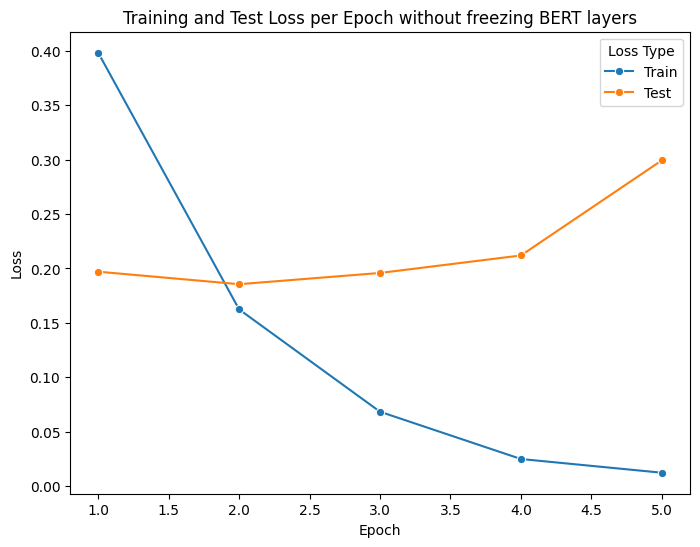

In [86]:
show_loss(train_losses, test_losses, title="Training and Test Loss per Epoch without freezing BERT layers")

#### Evaluating the Model

In [87]:
all_labels, all_preds = evaluate_model(model, test_loader, device)

labels: tensor([2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2, 1, 1, 1, 2, 2], device='cuda:0')
predictions: tensor([2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2, 1, 1, 1, 2, 2], device='cuda:0')
labels: tensor([1, 1, 1, 2, 2, 2, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1], device='cuda:0')
predictions: tensor([1, 1, 1, 2, 2, 2, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1], device='cuda:0')
labels: tensor([2, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2], device='cuda:0')
predictions: tensor([2, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2], device='cuda:0')
labels: tensor([1, 1, 1, 2, 2, 2, 0, 2, 0, 2, 1, 2, 1, 2, 1, 1], device='cuda:0')
predictions: tensor([1, 1, 1, 2, 2, 2, 0, 2, 0, 2, 1, 2, 1, 1, 1, 1], device='cuda:0')
labels: tensor([2, 2, 2, 1, 0, 1, 1, 1, 2, 0, 2, 1, 1, 2, 1, 1], device='cuda:0')
predictions: tensor([2, 2, 2, 1, 0, 1, 1, 1, 2, 0, 2, 1, 1, 2, 1, 1], device='cuda:0')
labels: tensor([2, 1, 2, 2, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2], device='cuda:0')
predictions: tensor([2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2], dev

In [88]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.97      0.71      0.82        51
           1       0.92      0.99      0.95       269
           2       0.95      0.93      0.94       187

    accuracy                           0.94       507
   macro avg       0.95      0.87      0.90       507
weighted avg       0.94      0.94      0.93       507



In [89]:
print(accuracy_score(all_labels, all_preds))

0.9368836291913215


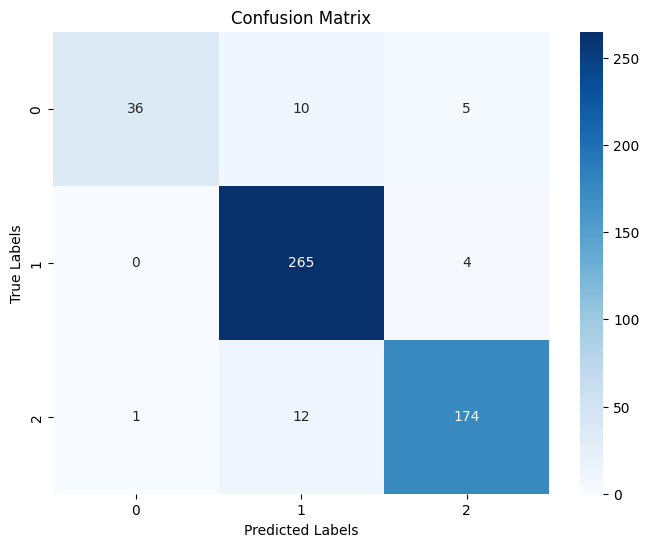

In [90]:
show_confusion_matrix(all_labels, all_preds)

In [91]:
# show_confusion_matrix(all_labels, all_preds, normalize="true")

#### Saving the model

In [92]:
torch.save(model.state_dict(), f"{PATH_TO_SAVE_MODEL}bertimbau-glassdoor-reviews-no-layer.bin")

#### Loading the model

In [93]:
loaded_model = GlassdoorReviewsClassifier(num_labels).to(device)
loaded_model.load_state_dict(torch.load(GLASSDOOR_MODEL_PATH, map_location=device))
loaded_model.eval()

<ipython-input-93-943f1caec82f>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(GLASSDOOR_MODEL_PATH, map_location=device))


GlassdoorReviewsClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

#### Sample prediction

In [94]:
predict_reviews(model, SAMPLE_REVIEWS)

Review text: Empresa boa para trabalhar
neutral     0.000070
positive    0.999843
negative    0.000088
Name: 0, dtype: float64


Review text: Empresa ruim para trabalhar
neutral     0.000177
positive    0.000512
negative    0.999311
Name: 0, dtype: float64


Review text: Não tenho o que declarar
neutral     0.997148
positive    0.001302
negative    0.001550
Name: 0, dtype: float64




### Training Model freezing BERT Layers

In [95]:
train_losses, test_losses = start_training(
    model_freezing, train_loader, loss_fun, optimizer_freezing, EPOCHS, n_total_steps
)

-------------------- Epoch: 1/5 --------------------
Training Batch 16/127, 		 loss = 0.7455
Training Batch 32/127, 		 loss = 0.2916
Training Batch 48/127, 		 loss = 0.1304
Training Batch 64/127, 		 loss = 0.3476
Training Batch 80/127, 		 loss = 0.4563
Training Batch 96/127, 		 loss = 0.3117
Training Batch 112/127, 		 loss = 0.2904

Evaluating Batch 16/127, 		 loss = 0.1880
Evaluating Batch 32/127, 		 loss = 0.0232

Train Loss: 0.37497318566842813, 		 Test Loss: 0.17284289660165086



-------------------- Epoch: 2/5 --------------------
Training Batch 16/127, 		 loss = 0.0210
Training Batch 32/127, 		 loss = 0.0283
Training Batch 48/127, 		 loss = 0.4718
Training Batch 64/127, 		 loss = 0.1117
Training Batch 80/127, 		 loss = 0.0604
Training Batch 96/127, 		 loss = 0.7276
Training Batch 112/127, 		 loss = 0.0211

Evaluating Batch 16/127, 		 loss = 0.0743
Evaluating Batch 32/127, 		 loss = 0.0120

Train Loss: 0.13894382529107369, 		 Test Loss: 0.17423789110034704



--------------------

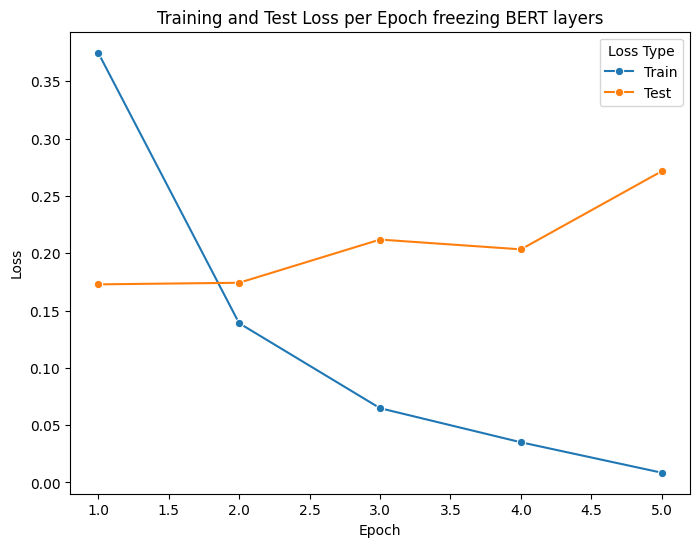

In [96]:
show_loss(train_losses, test_losses, title="Training and Test Loss per Epoch freezing BERT layers")

#### Evaluating the Model

In [97]:
all_labels, all_preds = evaluate_model(model_freezing, test_loader, device)

labels: tensor([2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2, 1, 1, 1, 2, 2], device='cuda:0')
predictions: tensor([2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2, 1, 1, 1, 2, 2], device='cuda:0')
labels: tensor([1, 1, 1, 2, 2, 2, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1], device='cuda:0')
predictions: tensor([1, 1, 1, 2, 2, 2, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1], device='cuda:0')
labels: tensor([2, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2], device='cuda:0')
predictions: tensor([2, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2], device='cuda:0')
labels: tensor([1, 1, 1, 2, 2, 2, 0, 2, 0, 2, 1, 2, 1, 2, 1, 1], device='cuda:0')
predictions: tensor([1, 1, 1, 2, 2, 2, 0, 2, 0, 2, 1, 2, 1, 2, 1, 1], device='cuda:0')
labels: tensor([2, 2, 2, 1, 0, 1, 1, 1, 2, 0, 2, 1, 1, 2, 1, 1], device='cuda:0')
predictions: tensor([2, 2, 2, 1, 0, 1, 1, 1, 2, 0, 2, 1, 1, 2, 1, 1], device='cuda:0')
labels: tensor([2, 1, 2, 2, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2], device='cuda:0')
predictions: tensor([2, 1, 2, 0, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2], dev

In [98]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.84      0.80      0.82        51
           1       0.94      0.96      0.95       269
           2       0.96      0.94      0.95       187

    accuracy                           0.94       507
   macro avg       0.91      0.90      0.91       507
weighted avg       0.94      0.94      0.94       507



In [99]:
print(accuracy_score(all_labels, all_preds))

0.9368836291913215


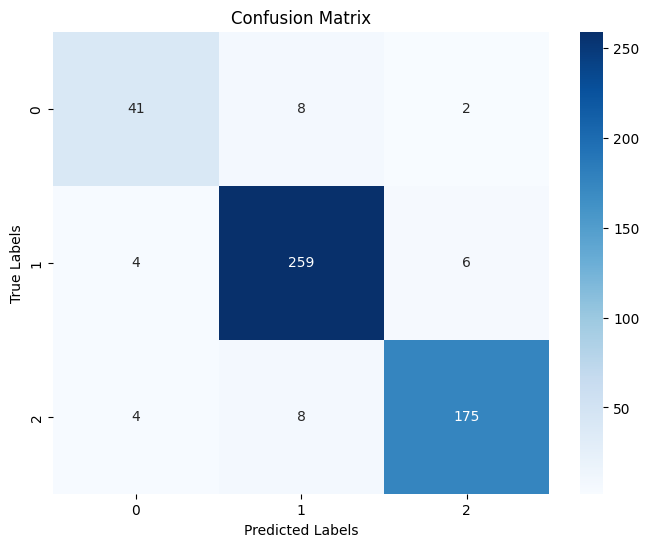

In [100]:
show_confusion_matrix(all_labels, all_preds)

In [101]:
# show_confusion_matrix(all_labels, all_preds, normalize="true")

#### Saving the model

In [102]:
torch.save(model.state_dict(), f"{PATH_TO_SAVE_MODEL}bertimbau-glassdoor-reviews-freezing-no-layer.bin")

#### Loading the model

In [103]:
loaded_model = GlassdoorReviewsClassifier(num_labels).to(device)
loaded_model.load_state_dict(torch.load(GLASSDOOR_FREEZING_MODEL_PATH, map_location=device))
loaded_model.eval()

<ipython-input-103-9eb54d819a40>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(GLASSDOOR_FREEZING_MODEL_PATH, map_location=device)

GlassdoorReviewsClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

##### Sample prediction

In [104]:
predict_reviews(loaded_model, SAMPLE_REVIEWS)

Review text: Empresa boa para trabalhar
neutral     0.000049
positive    0.999886
negative    0.000064
Name: 0, dtype: float64


Review text: Empresa ruim para trabalhar
neutral     0.000113
positive    0.000346
negative    0.999541
Name: 0, dtype: float64


Review text: Não tenho o que declarar
neutral     0.997918
positive    0.000926
negative    0.001156
Name: 0, dtype: float64




## Training the model (with oversampling)

### Oversampling

In [105]:
def oversampling(train_df, minority_class=0, majority_classes=[1, 2]):
    # Desired number of samples for the minority class
    oversample_size = (
        train_df[train_df["sentiment"] == 0]["sentiment"].value_counts()[0] * 3
    )

    oversampler = RandomOverSampler(sampling_strategy={minority_class: oversample_size})
    X_res, y_res = oversampler.fit_resample(
        train_df[["review_text"]], train_df["sentiment"]
    )

    y_res_df = pd.DataFrame({"sentiment": y_res})
    resampled_df = pd.concat([X_res, y_res_df], axis=1)
    resampled_df.reset_index(drop=True, inplace=True)

    resampled_minority_df = resampled_df[resampled_df["sentiment"] == minority_class]

    # Concatenate the oversampled minority class with the majority class
    oversampled_df = pd.concat([train_df, resampled_minority_df])

    # Shuffle the DataFrame to randomize the order of samples
    oversampled_df = oversampled_df.sample(
        frac=1, random_state=RANDOM_SEED
    ).reset_index(drop=True)
    return oversampled_df

In [106]:
filtered_dataset.shape

(2532, 2)

In [107]:
filtered_dataset["sentiment"].value_counts()

,count
sentiment,
1,1269
2,1021
0,242


In [108]:
oversampled_filtered_dataset = oversampling(filtered_dataset)

In [109]:
oversampled_filtered_dataset.shape

(3258, 2)

In [110]:
oversampled_filtered_dataset["sentiment"].value_counts()

,count
sentiment,
1,1269
2,1021
0,968


### Training the Model

In [111]:
oversampled_train_data, oversampled_test_data = train_test_split(
    oversampled_filtered_dataset, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

In [112]:
oversampled_train_dataset = GlassdoorReviewsDataset(
    oversampled_train_data, tokenizer, TOKEN_MAX_LENGTH
)

oversampled_test_dataset = GlassdoorReviewsDataset(
    oversampled_test_data, tokenizer, TOKEN_MAX_LENGTH
)

In [113]:
oversampled_train_loader = DataLoader(
    oversampled_train_dataset, batch_size=BATCH_SIZE, shuffle=True
)
oversampled_test_loader = DataLoader(
    oversampled_test_dataset, batch_size=BATCH_SIZE, shuffle=False
)

In [114]:
oversampled_model = GlassdoorReviewsClassifier(num_labels).to(device)
oversampled_model_freezing = GlassdoorReviewsClassifierFreezing(num_labels).to(device)

In [115]:
loss_fun = nn.CrossEntropyLoss()

In [116]:
oversampled_optimizer = torch.optim.Adam(
    oversampled_model.parameters(), lr=LEARNING_RATE
)
oversampled_optimizer_freezing = torch.optim.Adam(
    oversampled_model_freezing.parameters(), lr=LEARNING_RATE
)

In [117]:
n_total_steps = len(oversampled_train_loader)
n_total_steps

163

#### Train without freezing

In [118]:
oversampled_train_losses, oversampled_test_losses = start_training(
    oversampled_model,
    oversampled_train_loader,
    loss_fun,
    oversampled_optimizer,
    EPOCHS,
    n_total_steps,
)

-------------------- Epoch: 1/5 --------------------
Training Batch 16/163, 		 loss = 0.7397
Training Batch 32/163, 		 loss = 0.6024
Training Batch 48/163, 		 loss = 0.7088
Training Batch 64/163, 		 loss = 0.5677
Training Batch 80/163, 		 loss = 0.6669
Training Batch 96/163, 		 loss = 0.2121
Training Batch 112/163, 		 loss = 0.1816
Training Batch 128/163, 		 loss = 0.2116
Training Batch 144/163, 		 loss = 0.1189
Training Batch 160/163, 		 loss = 0.1120

Evaluating Batch 16/163, 		 loss = 0.2058
Evaluating Batch 32/163, 		 loss = 0.0281

Train Loss: 0.34408166070977236, 		 Test Loss: 0.10503306391183287



-------------------- Epoch: 2/5 --------------------
Training Batch 16/163, 		 loss = 0.0620
Training Batch 32/163, 		 loss = 0.0534
Training Batch 48/163, 		 loss = 0.2689
Training Batch 64/163, 		 loss = 0.0294
Training Batch 80/163, 		 loss = 0.0111
Training Batch 96/163, 		 loss = 0.0394
Training Batch 112/163, 		 loss = 0.3462
Training Batch 128/163, 		 loss = 0.0232
Training Bat

##### Evaluating the Model

In [119]:
len(oversampled_train_losses)

5

In [120]:
len(oversampled_test_losses)

5

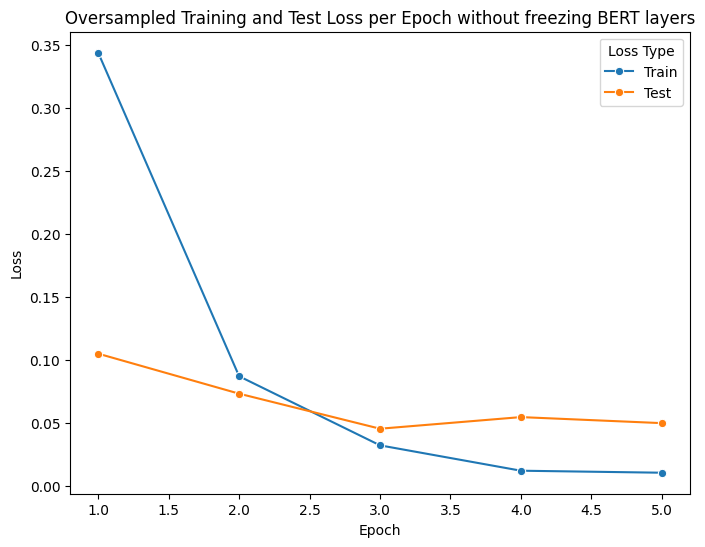

In [121]:
show_loss(oversampled_train_losses, oversampled_test_losses, title="Oversampled Training and Test Loss per Epoch without freezing BERT layers")

In [122]:
oversampled_all_labels, oversampled_all_preds = evaluate_model(
    oversampled_model, oversampled_test_loader, device
)

labels: tensor([1, 1, 1, 1, 0, 2, 2, 2, 2, 2, 1, 1, 1, 0, 2, 1], device='cuda:0')
predictions: tensor([1, 1, 1, 1, 0, 2, 1, 2, 2, 2, 1, 1, 1, 0, 2, 1], device='cuda:0')
labels: tensor([0, 2, 1, 1, 1, 1, 2, 1, 2, 0, 1, 2, 2, 2, 1, 1], device='cuda:0')
predictions: tensor([0, 2, 1, 1, 1, 1, 2, 1, 2, 0, 1, 2, 2, 2, 1, 1], device='cuda:0')
labels: tensor([1, 2, 2, 0, 0, 2, 2, 2, 2, 1, 2, 0, 0, 2, 2, 1], device='cuda:0')
predictions: tensor([1, 2, 2, 0, 0, 2, 2, 2, 2, 1, 2, 0, 0, 2, 2, 1], device='cuda:0')
labels: tensor([2, 1, 1, 1, 1, 1, 2, 0, 2, 0, 1, 1, 2, 0, 1, 0], device='cuda:0')
predictions: tensor([2, 1, 1, 1, 1, 1, 2, 0, 2, 0, 1, 1, 2, 0, 1, 0], device='cuda:0')
labels: tensor([2, 0, 0, 1, 1, 0, 2, 0, 1, 0, 0, 0, 1, 1, 1, 0], device='cuda:0')
predictions: tensor([2, 0, 0, 1, 1, 0, 2, 0, 1, 0, 0, 0, 1, 1, 1, 0], device='cuda:0')
labels: tensor([0, 2, 2, 1, 2, 2, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1], device='cuda:0')
predictions: tensor([0, 2, 2, 1, 2, 2, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1], dev

In [123]:
print(classification_report(oversampled_all_labels, oversampled_all_preds))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       197
           1       0.95      0.98      0.96       256
           2       0.98      0.92      0.95       199

    accuracy                           0.96       652
   macro avg       0.96      0.96      0.96       652
weighted avg       0.96      0.96      0.96       652



In [124]:
print(accuracy_score(oversampled_all_labels, oversampled_all_preds))

0.9601226993865031


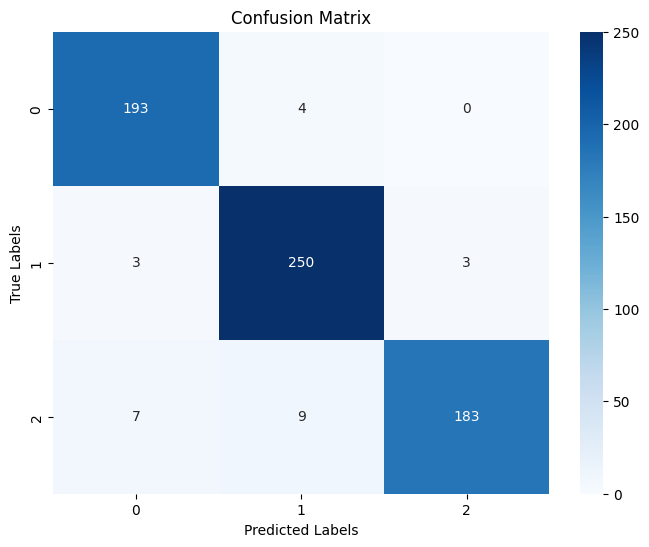

In [125]:
show_confusion_matrix(oversampled_all_labels, oversampled_all_preds)

##### Saving the model

In [126]:
torch.save(
    oversampled_model.state_dict(),
    f"{PATH_TO_SAVE_MODEL}bertimbau-glassdoor-reviews-oversampled-no-layer.bin",
)

##### Loading the model

In [127]:
oversampled_model = GlassdoorReviewsClassifier(num_labels).to(device)
oversampled_model.load_state_dict(
    torch.load(
        GLASSDOOR_MODEL_PATH.replace(
            f"bertimbau-glassdoor-reviews-no-layer.bin",
            f"bertimbau-glassdoor-reviews-oversampled-no-layer.bin",
        ),
        map_location=device,
    )
)
oversampled_model.eval()

<ipython-input-127-c587ae8da161>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


GlassdoorReviewsClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

##### Sample prediction

In [128]:
predict_reviews(oversampled_model, SAMPLE_REVIEWS)

Review text: Empresa boa para trabalhar
neutral     0.000044
positive    0.999863
negative    0.000093
Name: 0, dtype: float64


Review text: Empresa ruim para trabalhar
neutral     0.000139
positive    0.010530
negative    0.989331
Name: 0, dtype: float64


Review text: Não tenho o que declarar
neutral     0.999344
positive    0.000573
negative    0.000083
Name: 0, dtype: float64




#### Train freezing

In [129]:
oversampled_train_losses, oversampled_test_losses = start_training(
    oversampled_model_freezing,
    oversampled_train_loader,
    loss_fun,
    oversampled_optimizer_freezing,
    EPOCHS,
    n_total_steps,
)

-------------------- Epoch: 1/5 --------------------
Training Batch 16/163, 		 loss = 0.7327
Training Batch 32/163, 		 loss = 0.1543
Training Batch 48/163, 		 loss = 0.3426
Training Batch 64/163, 		 loss = 0.2505
Training Batch 80/163, 		 loss = 0.2430
Training Batch 96/163, 		 loss = 0.3722
Training Batch 112/163, 		 loss = 0.0294
Training Batch 128/163, 		 loss = 0.4709
Training Batch 144/163, 		 loss = 0.2068
Training Batch 160/163, 		 loss = 0.1406

Evaluating Batch 16/163, 		 loss = 0.3959
Evaluating Batch 32/163, 		 loss = 0.0264

Train Loss: 0.34451111801471446, 		 Test Loss: 0.1710723140859045



-------------------- Epoch: 2/5 --------------------
Training Batch 16/163, 		 loss = 0.0676
Training Batch 32/163, 		 loss = 0.1073
Training Batch 48/163, 		 loss = 0.0218
Training Batch 64/163, 		 loss = 0.0230
Training Batch 80/163, 		 loss = 0.0165
Training Batch 96/163, 		 loss = 0.0139
Training Batch 112/163, 		 loss = 0.0185
Training Batch 128/163, 		 loss = 0.0048
Training Batc

##### Evaluating the Model

In [130]:
len(oversampled_train_losses)

5

In [131]:
len(oversampled_test_losses)

5

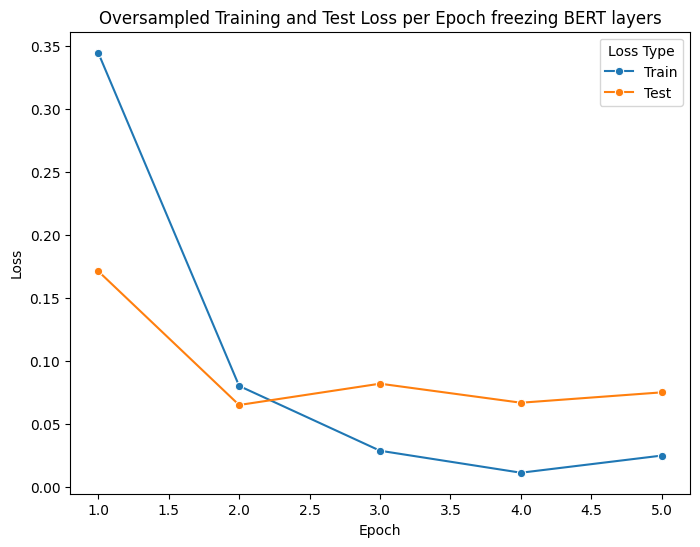

In [132]:
show_loss(
    oversampled_train_losses,
    oversampled_test_losses,
    title="Oversampled Training and Test Loss per Epoch freezing BERT layers",
)

In [133]:
oversampled_all_labels, oversampled_all_preds = evaluate_model(
    oversampled_model_freezing, oversampled_test_loader, device
)

labels: tensor([1, 1, 1, 1, 0, 2, 2, 2, 2, 2, 1, 1, 1, 0, 2, 1], device='cuda:0')
predictions: tensor([1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 1, 1, 1, 0, 2, 1], device='cuda:0')
labels: tensor([0, 2, 1, 1, 1, 1, 2, 1, 2, 0, 1, 2, 2, 2, 1, 1], device='cuda:0')
predictions: tensor([0, 2, 1, 1, 1, 1, 2, 1, 2, 0, 1, 2, 2, 2, 1, 1], device='cuda:0')
labels: tensor([1, 2, 2, 0, 0, 2, 2, 2, 2, 1, 2, 0, 0, 2, 2, 1], device='cuda:0')
predictions: tensor([1, 2, 2, 0, 0, 2, 2, 2, 2, 1, 2, 0, 0, 2, 2, 1], device='cuda:0')
labels: tensor([2, 1, 1, 1, 1, 1, 2, 0, 2, 0, 1, 1, 2, 0, 1, 0], device='cuda:0')
predictions: tensor([2, 1, 1, 1, 1, 1, 2, 0, 2, 0, 1, 1, 2, 0, 1, 0], device='cuda:0')
labels: tensor([2, 0, 0, 1, 1, 0, 2, 0, 1, 0, 0, 0, 1, 1, 1, 0], device='cuda:0')
predictions: tensor([2, 0, 0, 1, 1, 0, 2, 0, 1, 0, 0, 0, 1, 1, 1, 0], device='cuda:0')
labels: tensor([0, 2, 2, 1, 2, 2, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1], device='cuda:0')
predictions: tensor([0, 2, 2, 1, 2, 2, 1, 0, 1, 0, 0, 2, 0, 1, 0, 1], dev

In [134]:
print(classification_report(oversampled_all_labels, oversampled_all_preds))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       197
           1       0.96      0.94      0.95       256
           2       0.96      0.90      0.93       199

    accuracy                           0.94       652
   macro avg       0.94      0.94      0.94       652
weighted avg       0.94      0.94      0.94       652



In [135]:
print(accuracy_score(oversampled_all_labels, oversampled_all_preds))

0.9401840490797546


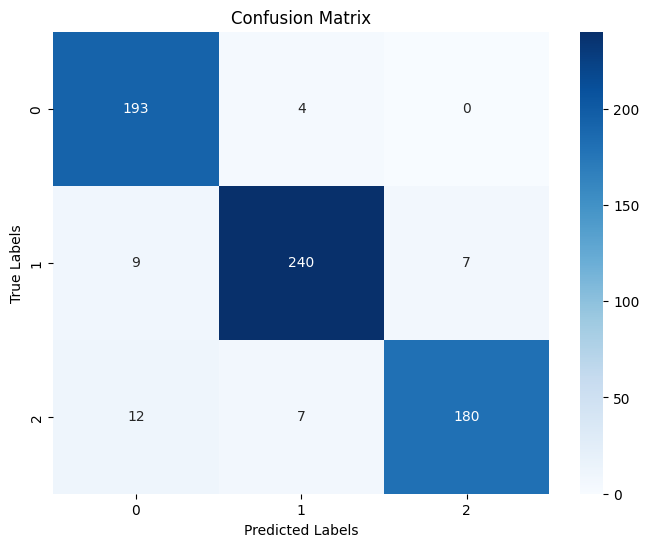

In [136]:
show_confusion_matrix(oversampled_all_labels, oversampled_all_preds)

##### Saving the model

In [137]:
torch.save(
    oversampled_model.state_dict(),
    f"{PATH_TO_SAVE_MODEL}bertimbau-glassdoor-reviews-oversampled-freezing-no-layer.bin",
)

##### Loading the model

In [138]:
oversampled_model = GlassdoorReviewsClassifier(num_labels).to(device)
oversampled_model.load_state_dict(
    torch.load(
        GLASSDOOR_MODEL_PATH.replace(
            f"bertimbau-glassdoor-reviews-no-layer.bin",
            f"bertimbau-glassdoor-reviews-oversampled-freezing-no-layer.bin",
        ),
        map_location=device,
    )
)
oversampled_model.eval()

<ipython-input-138-f5b571a2038d>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


GlassdoorReviewsClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

##### Sample prediction

In [139]:
predict_reviews(oversampled_model, SAMPLE_REVIEWS)

Review text: Empresa boa para trabalhar
neutral     0.00003
positive    0.99990
negative    0.00007
Name: 0, dtype: float64


Review text: Empresa ruim para trabalhar
neutral     0.000088
positive    0.008369
negative    0.991543
Name: 0, dtype: float64


Review text: Não tenho o que declarar
neutral     0.999549
positive    0.000397
negative    0.000054
Name: 0, dtype: float64


